<a href="https://colab.research.google.com/github/peperjet/bc-ml/blob/main/dacon/wine4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

와인 품질(Quality)분류 경진대회
https://www.dacon.io/competitions/open/235610/overview/description

In [85]:
# 라이브러리 로딩
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt


# 경고 메세지 숨기기
import warnings
warnings.filterwarnings('ignore')


In [86]:
# 데이터 불러오기
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

간단한 EDA

In [87]:
# train 데이터의 개형을 살펴봅니다
# index를 제외하면 총 13개 변수를 가집니다.

train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,white
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,red
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,white
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,white
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,white


- index : 구분자
- quality : 품질
- fixed acidity : 산도
- volatile acidity : 휘발성산
- citric acid : 시트르산
- residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
- chlorides : 염화물
- free sulfur dioxide : 독립 이산화황
- total sulfur dioxide : 총 이산화황
- density : 밀도
- pH : 수소이온농도
- sulphates : 황산염
- alcohol : 도수
- type : 종류



In [88]:
# test 데이터의 개형을 살펴봅니다
# index를 제외하면 총 12개 변수를 가집니다.
# train 중 quality 변수가 사라졌습니다.
test.head()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,9.0,0.31,0.48,6.6,0.043,11.0,73.0,0.99380,2.90,0.38,11.6,white
1,1,13.3,0.43,0.58,1.9,0.070,15.0,40.0,1.00040,3.06,0.49,9.0,red
2,2,6.5,0.28,0.27,5.2,0.040,44.0,179.0,0.99480,3.19,0.69,9.4,white
3,3,7.2,0.15,0.39,1.8,0.043,21.0,159.0,0.99480,3.52,0.47,10.0,white
4,4,6.8,0.26,0.26,2.0,0.019,23.5,72.0,0.99041,3.16,0.47,11.8,white


In [89]:
# tain 데이터의 열 별 정보를 살펴봅니다.
# 결측치는 없습니다
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5497 entries, 0 to 5496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 5497 non-null   int64  
 1   quality               5497 non-null   int64  
 2   fixed acidity         5497 non-null   float64
 3   volatile acidity      5497 non-null   float64
 4   citric acid           5497 non-null   float64
 5   residual sugar        5497 non-null   float64
 6   chlorides             5497 non-null   float64
 7   free sulfur dioxide   5497 non-null   float64
 8   total sulfur dioxide  5497 non-null   float64
 9   density               5497 non-null   float64
 10  pH                    5497 non-null   float64
 11  sulphates             5497 non-null   float64
 12  alcohol               5497 non-null   float64
 13  type                  5497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 601.4+ KB


히트맵(heatmap)

<Axes: >

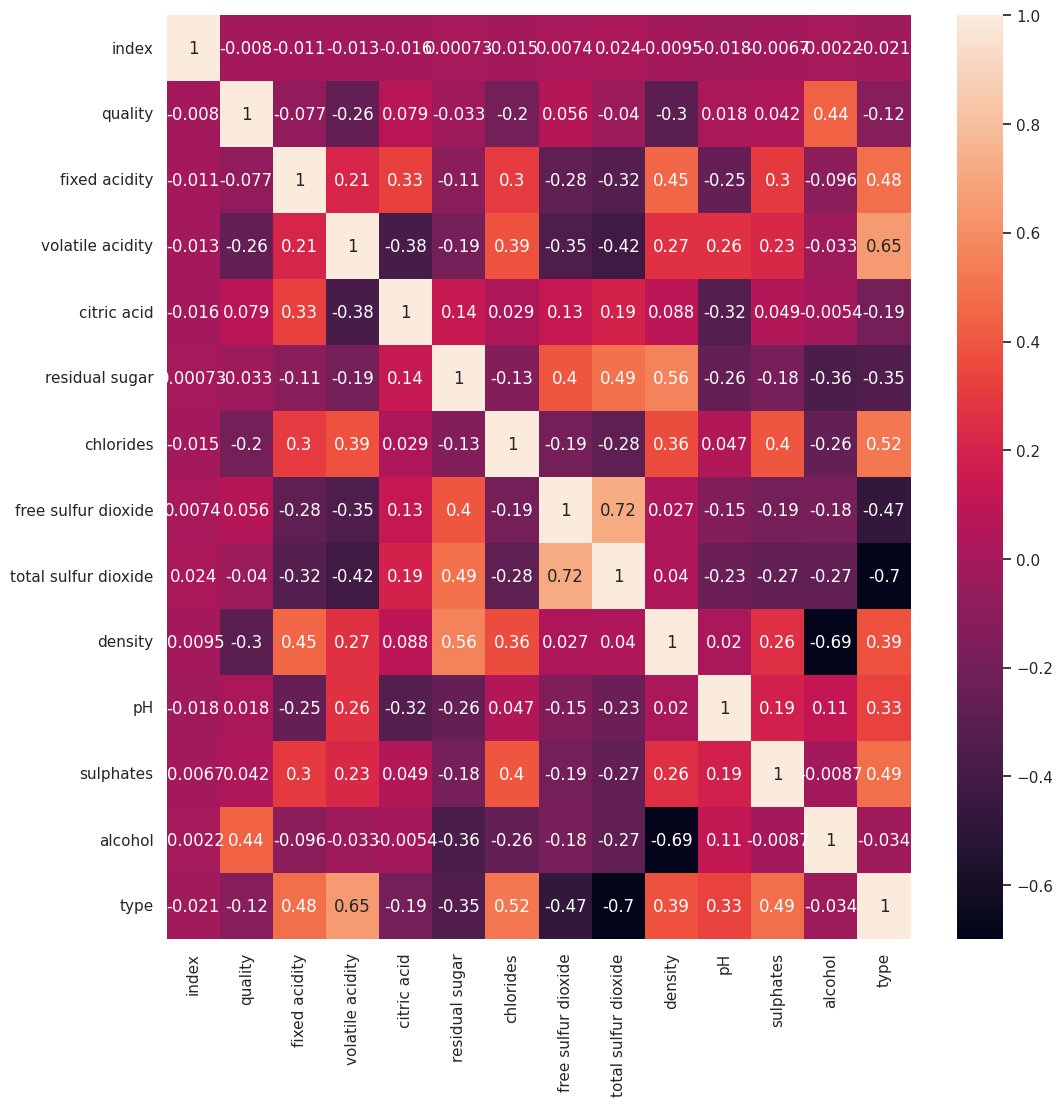

In [90]:
# train의 변수 간 상관관계를 살펴봅니다.
# 'type' 컬럼을 숫자로 변환합니다 (예: white=0, red=1)
train_corr = train.copy()
train_corr['type'] = train_corr['type'].map({'white': 0, 'red': 1})

plt.figure(figsize=(12,12))
sns.heatmap(data = train_corr.corr(), annot=True)

히스토그램(histogram)

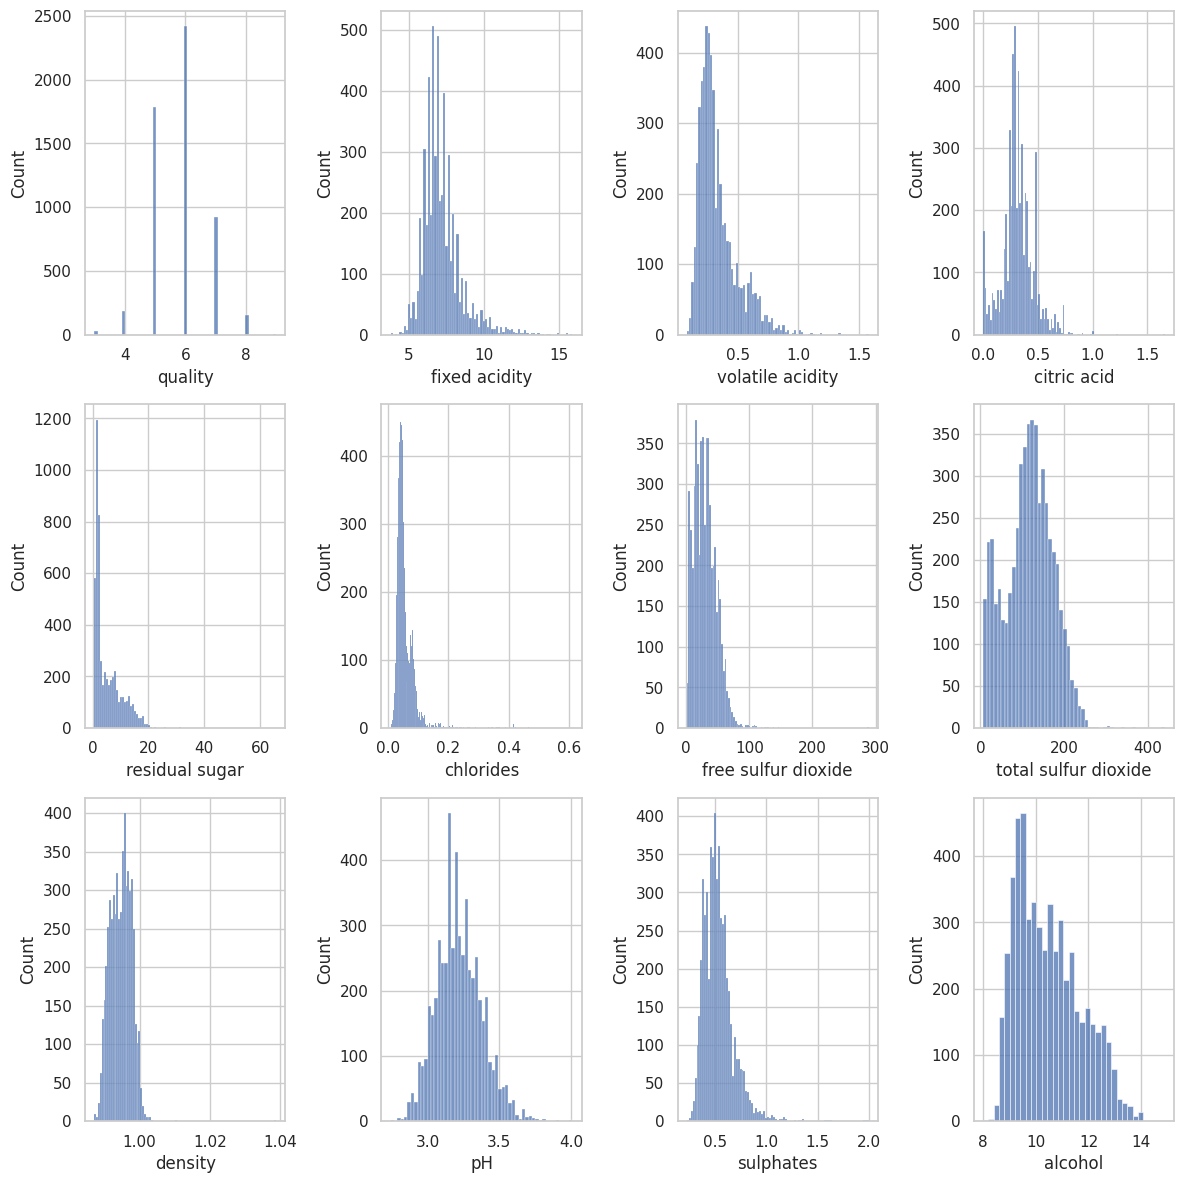

In [91]:
# train의 각 변수별 분포를 살펴보자
plt.figure(figsize=(12,12))
for i in range(1,13):
    plt.subplot(3,4,i)
    sns.histplot(train.iloc[:,i]) # 데이터가 어떻게 퍼져있는지 보여주는 함수

plt.tight_layout()
plt.show()

바플롯(barplot)

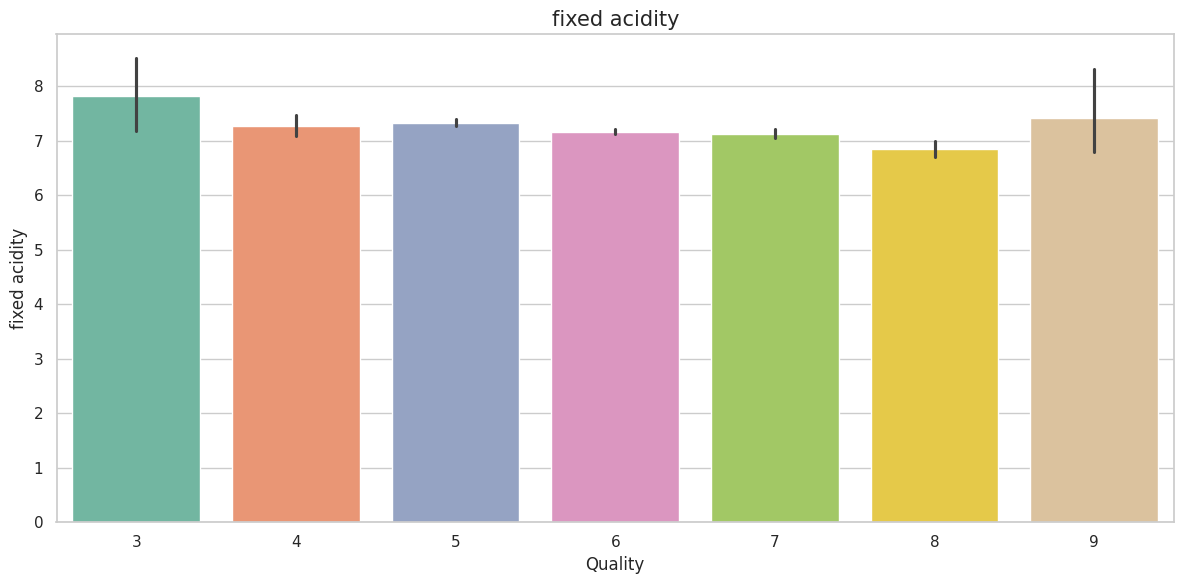

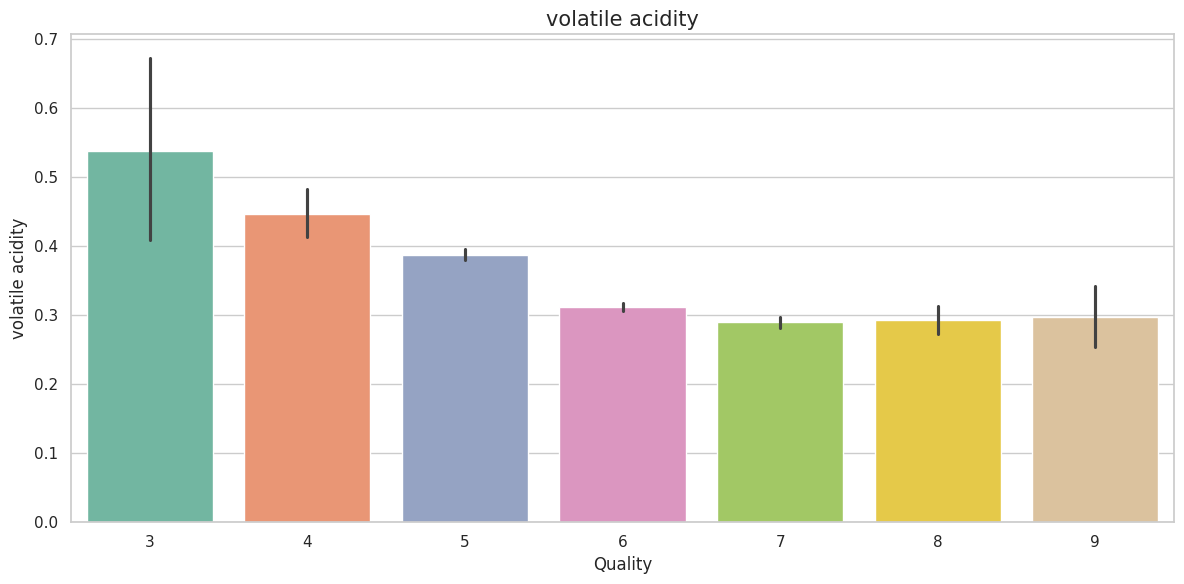

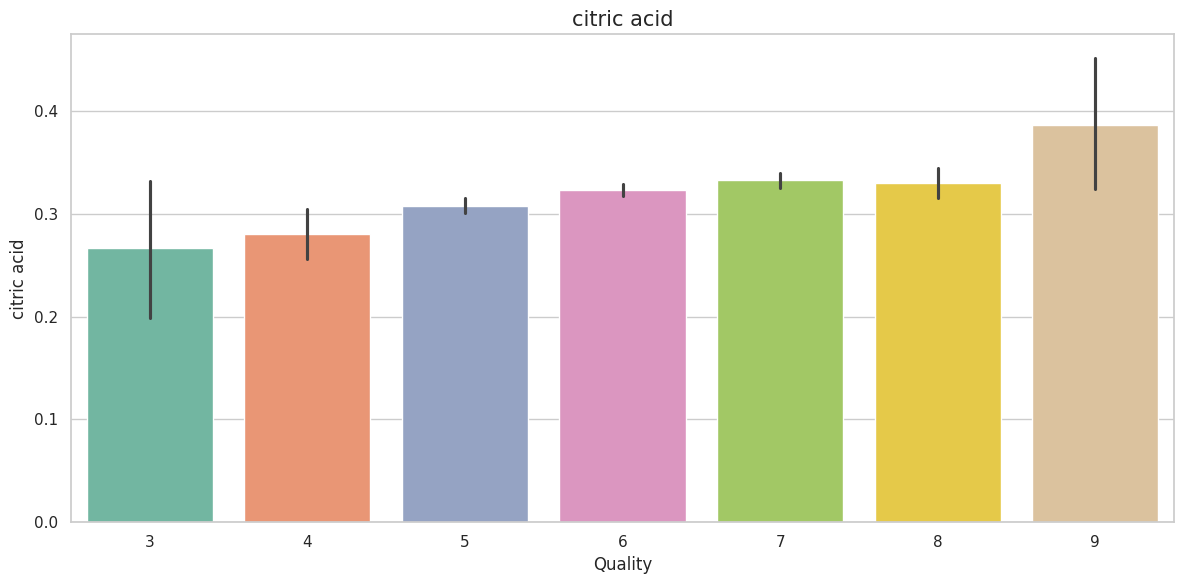

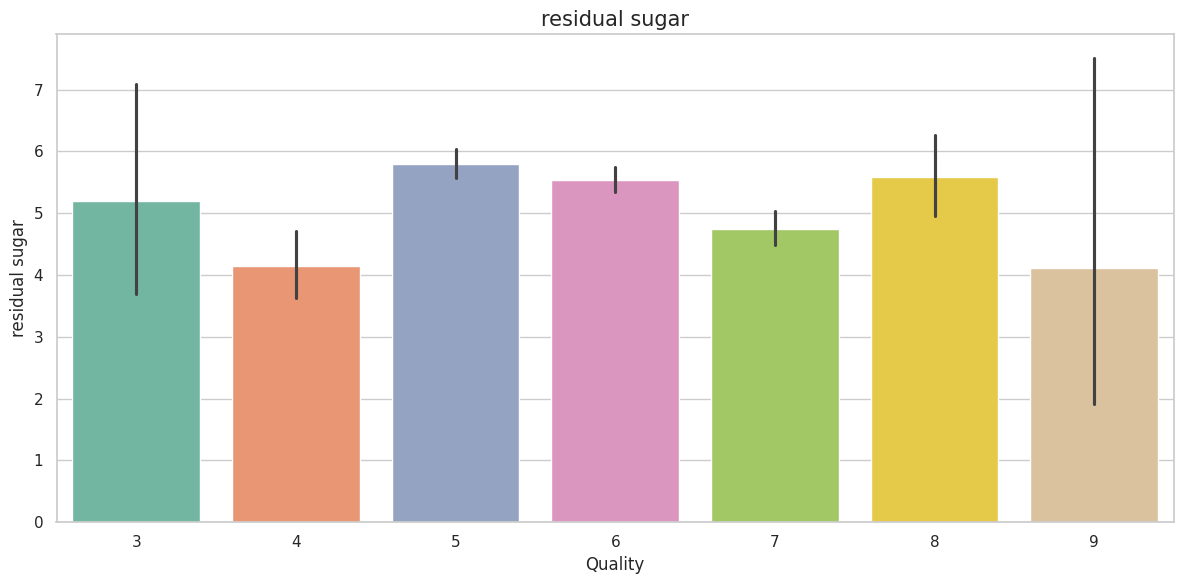

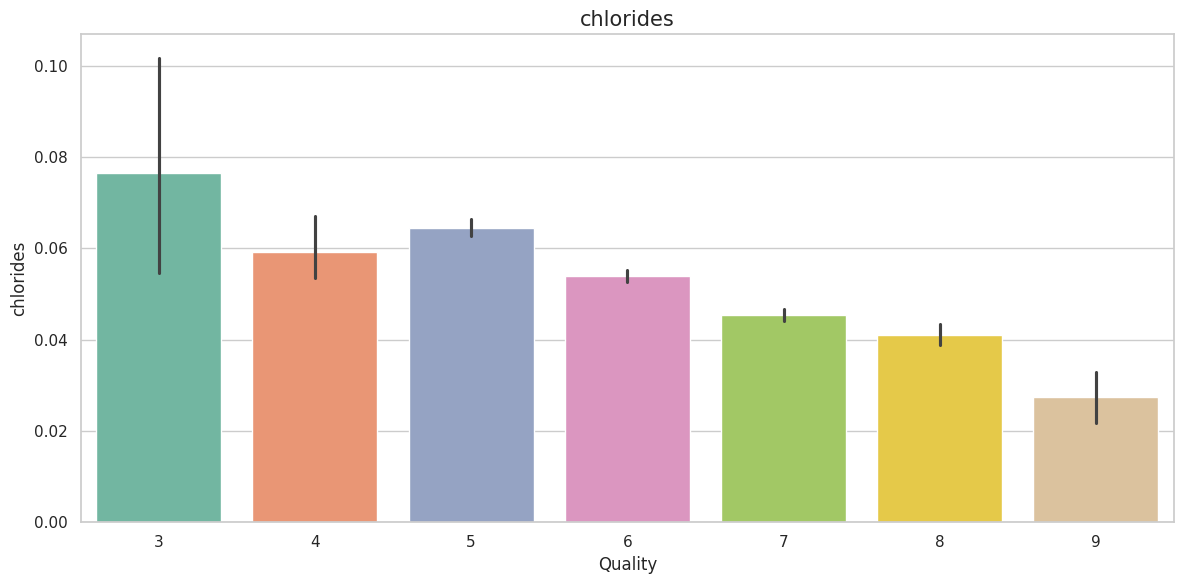

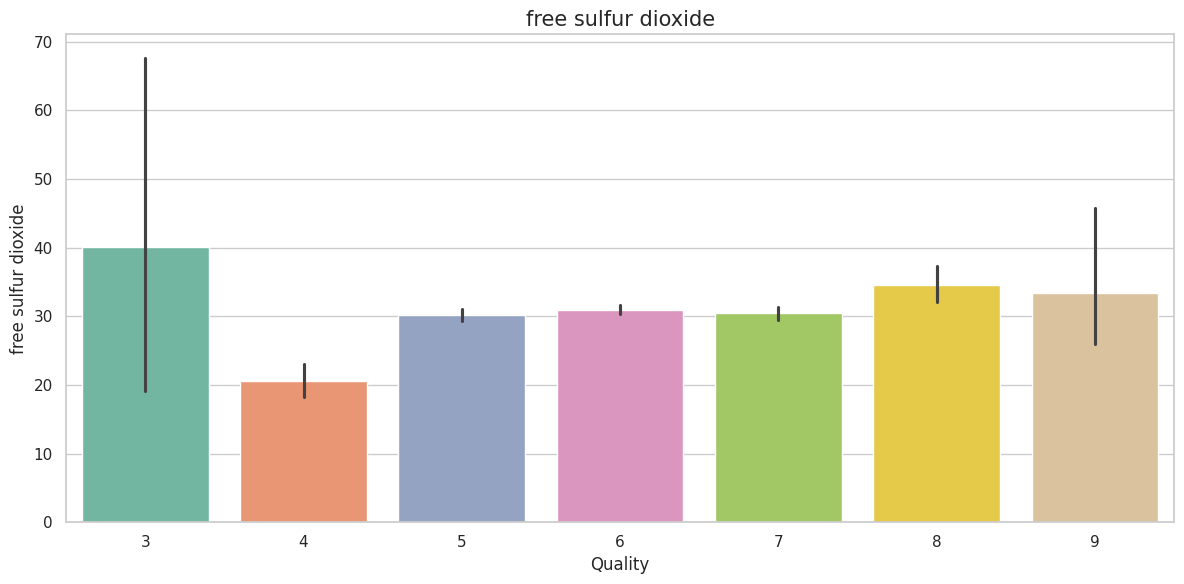

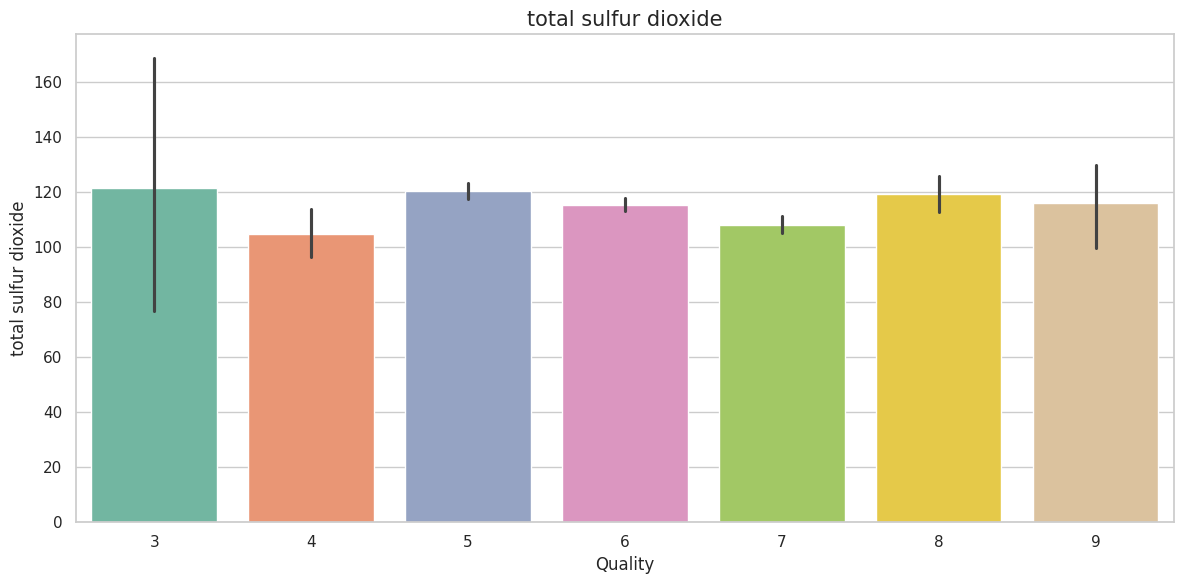

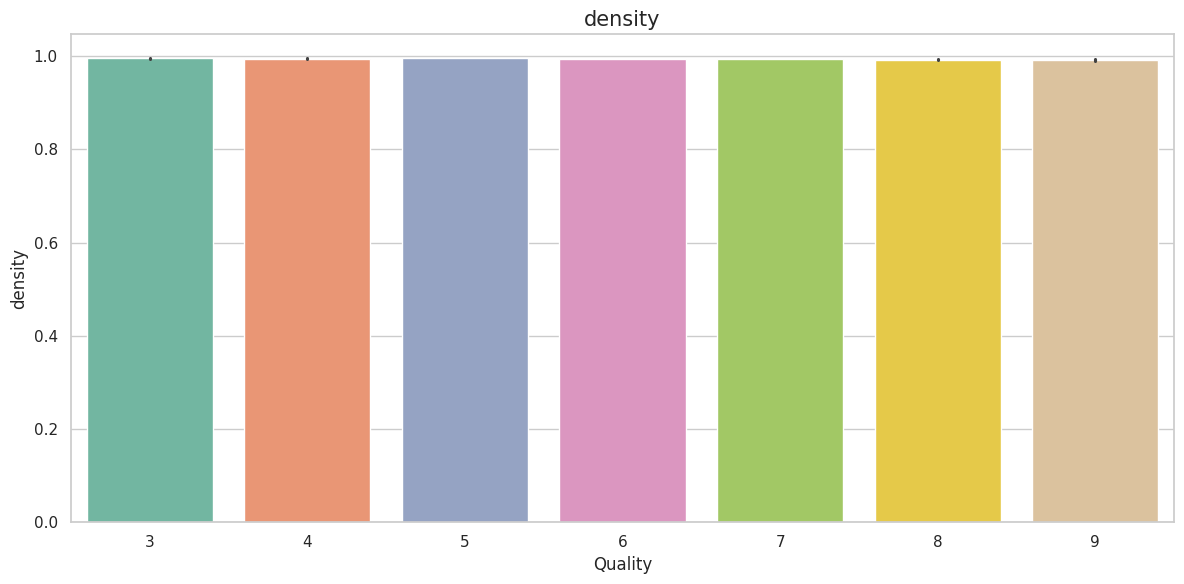

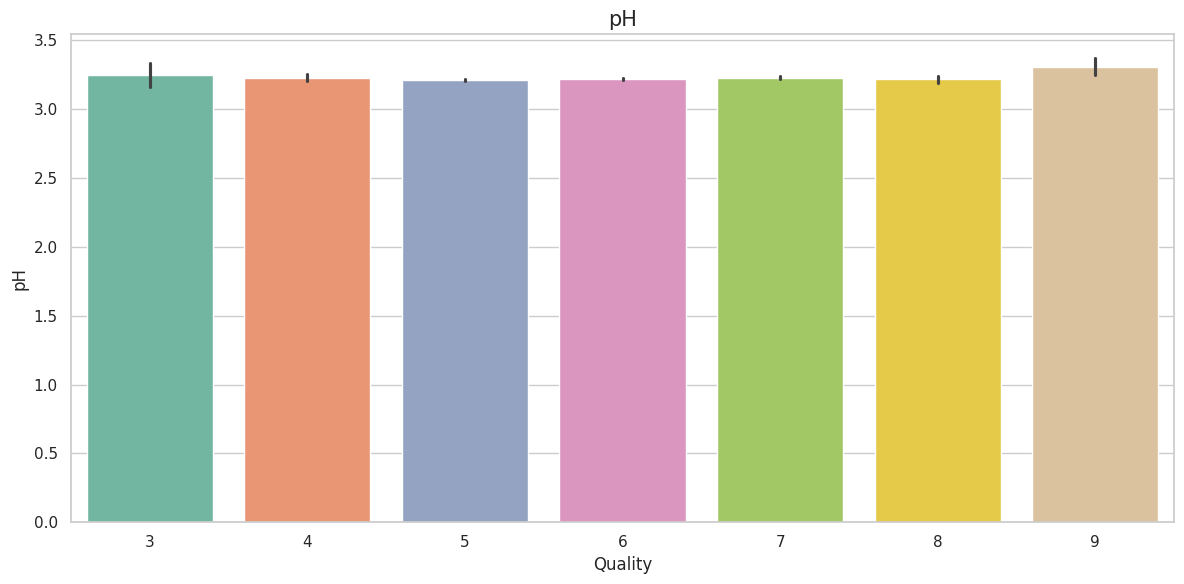

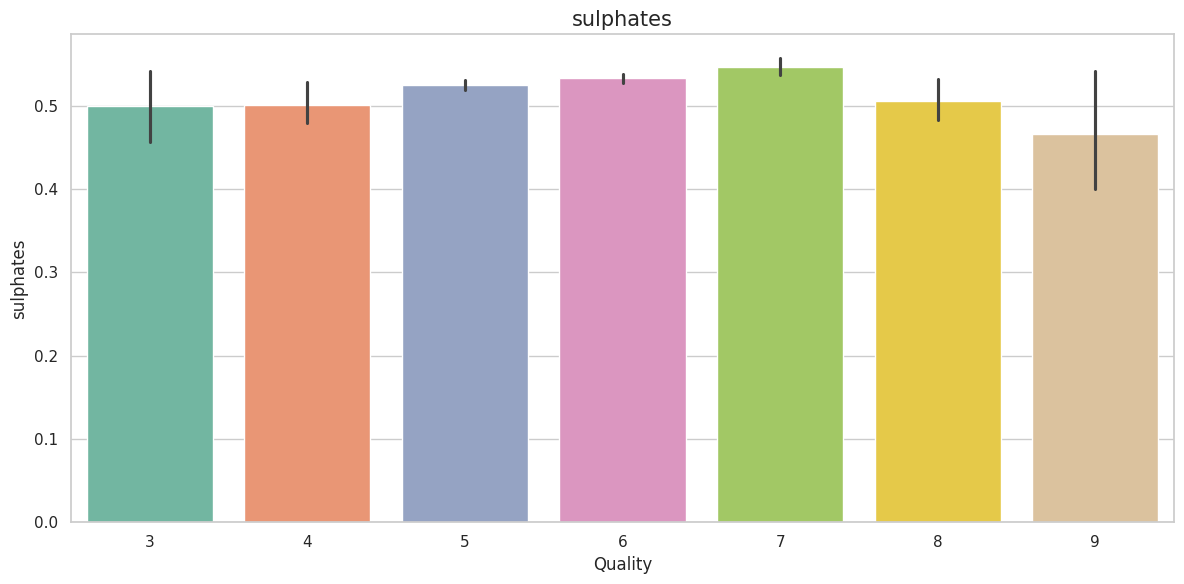

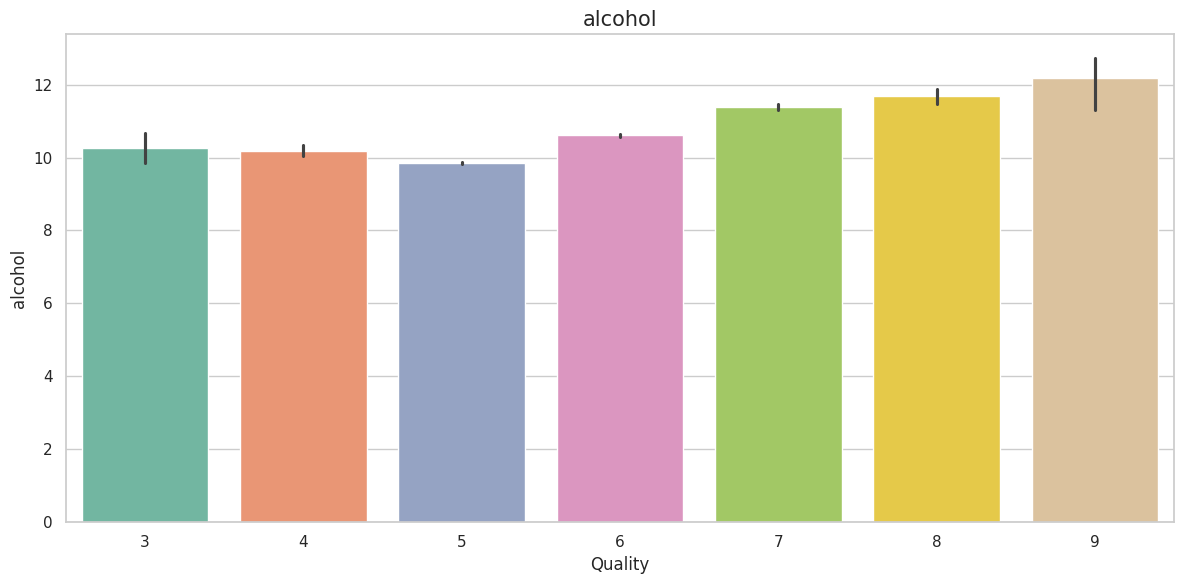

In [92]:
# train에서 각 변수와 quality 변수 사이 분포를 확인합시다

sns.set(style="whitegrid") # 배경 깔끔하게

for i in range(11):
  plt.figure(figsize  = (12,6))

  sns.barplot(
      x = 'quality',
      y = train.columns[i+2],
      data = train,
      palette = 'Set2' # 컬러풀하게
  )


  plt.title(train.columns[i+2], fontsize=15)
  plt.xlabel('Quality', fontsize=12)
  plt.ylabel(train.columns[i+2], fontsize=12)


  plt.tight_layout()
  plt.show()

데이터 전처리

In [93]:
# 데이터 전처리를 위해 train과 test 데이터를 다시 로드합니다.
# 이렇게 하면 'type' 컬럼이 다시 'white', 'red' 문자열 상태로 돌아옵니다.
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [94]:
# type에는 white와 red 두 종류가 있습니다
# 각각 0,1로 변환합니다.
# 사용자의 제안에 따라 map 함수를 사용하여 명시적으로 변환합니다.

train['type'] = train['type'].map({'white': 0, 'red': 1})
test['type'] = test['type'].map({'white': 0, 'red': 1})

In [95]:
# alcohol_density 피처 생성
train['alcohol_density'] = train['alcohol'] / train['density']
test['alcohol_density'] = test['alcohol'] / test['density']

기존 `q--HQ098bqoC` 셀의 기능을 이 위치로 옮겼으므로, 원본 셀을 제거합니다.

In [96]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,alcohol_density
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,0,10.258267
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,1,9.529542
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,0,10.990562
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,0,10.866284
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,0,10.949272


In [97]:
# 불필요한 변수 제거
train_x = train.drop(['index', 'quality'], axis=1)
train_y = train['quality']
test_x = test.drop(['index'], axis=1)

In [98]:
train_x.shape, train_y.shape, test_x.shape

((5497, 13), (5497,), (1000, 13))

모델링 진행

In [99]:
from sklearn.ensemble import RandomForestClassifier
# 모델선언
model = RandomForestClassifier()

# 모델학습
model.fit(train_x, train_y)

RandomForestClassifier()

In [100]:
# 학습화 된 모델로 test 데이터 예측
y_pred = model.predict(test_x)

제출 파일 생성

In [101]:
submission = pd.read_csv('sample_submission.csv')
submission['quality']=y_pred
submission

,index,quality
0,0,6
1,1,6
2,2,6
3,3,5
4,4,6
...,...,...
995,995,6
996,996,6
997,997,5
998,998,6


In [102]:
# csv 파일로 저장
submission.to_csv('baseline.csv', index=False)

In [103]:
# train['alcohol_density'] = train['alcohol'] / train['density']
# test['alcohol_density'] = test['alcohol'] / test['density']
# 기존 기능이 다른 셀로 이동되었으므로 주석 처리 또는 제거합니다.

In [104]:
from sklearn.model_selection import train_test_split

# 검증 추가

X = train.drop(['index', 'quality'], axis=1)
y = train['quality']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [105]:
# 기존 랜덤포레스트 그대로 사용
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [106]:
from sklearn.metrics import accuracy_score

# 검증 점수 확인 (중요)

pred = model.predict(X_valid)
print("Accuracy:", accuracy_score(y_valid, pred))

Accuracy: 0.6509090909090909


In [107]:
# 검증 검수 먼저 확인
pred = model.predict(X_valid)
acc = accuracy_score(y_valid, pred)
print("Accuracy:", acc)

Accuracy: 0.6509090909090909


In [108]:
# 라이브러리 추가

In [109]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

랜덤포레스트 모델 만들기

In [110]:
rf_model = RandomForestClassifier(random_state=42)

In [111]:
from sklearn.model_selection import cross_val_score

# 교차검증 실행

scores = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')

In [112]:
print("각 폴드 정확도:", scores)
print("평균 정확도:", scores.mean())

각 폴드 정확도: [0.68545455 0.67090909 0.65787079 0.67788899 0.65878071]
평균 정확도: 0.670180825543883


### 하이퍼파라미터 튜닝: RandomForestClassifier

In [113]:
from sklearn.model_selection import GridSearchCV

# RandomForestClassifier 모델 정의 (이전에 사용된 model 변수를 사용)
model = RandomForestClassifier(random_state=42)

# 튜닝할 하이퍼파라미터 범위 설정
param_grid = {
    'max_depth': [10, 20, 30, None], # None은 깊이 제한 없음
    'n_estimators': [100, 200, 300]
}

# GridSearchCV 객체 생성
# cv=skf (StratifiedKFold)를 사용하여 클래스 불균형을 고려한 교차 검증 수행
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)

# 데이터 (X, y는 전체 train 데이터)에 Grid Search 수행
grid_search.fit(X, y)

# 최적의 하이퍼파라미터와 최고 점수 출력
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 교차 검증 정확도:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
최적 하이퍼파라미터: {'max_depth': 20, 'n_estimators': 200}
최고 교차 검증 정확도: 0.6732750434279097


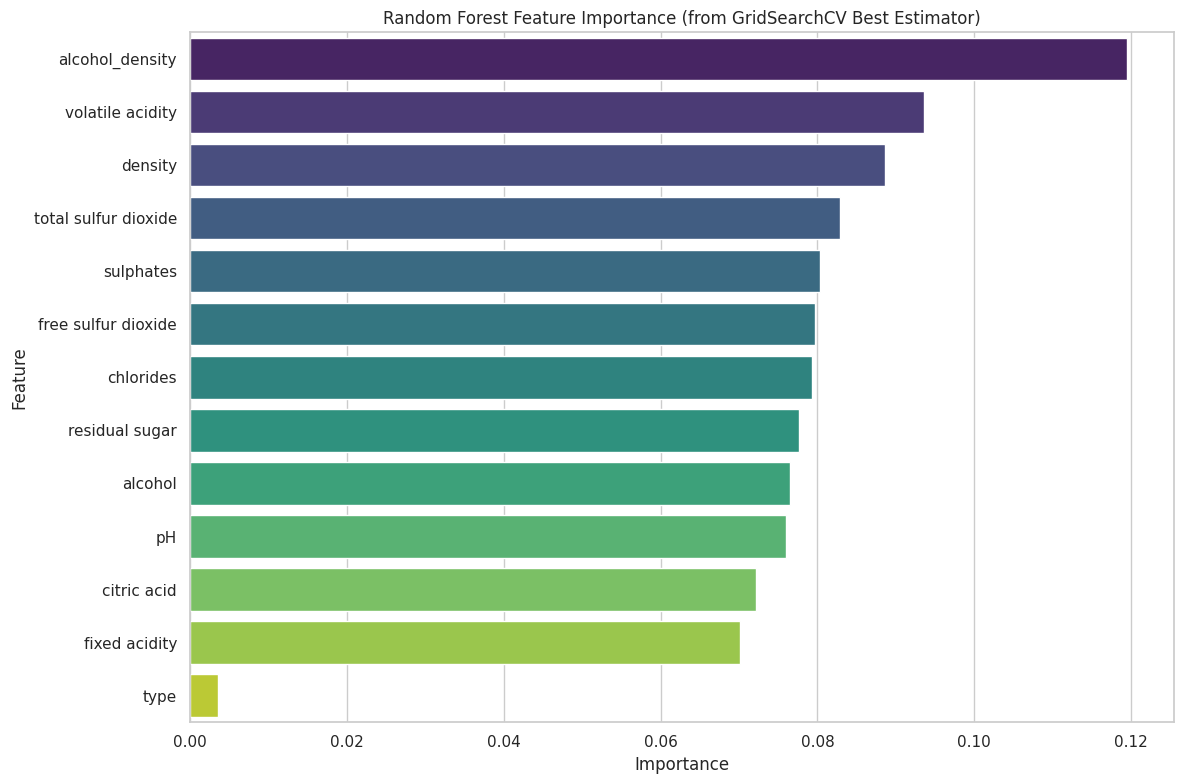

In [114]:
# 랜덤 포레스트 피처 중요도 추출
# 'model' 변수가 직접 학습되지 않았으므로, GridSearchCV의 최적 모델을 사용합니다.
rf_feature_importances = grid_search.best_estimator_.feature_importances_
# feature_names는 GridSearchCV 학습 시 사용된 X의 컬럼을 사용합니다.
rf_feature_names = X.columns

# 피처 중요도를 데이터프레임으로 생성
rf_importance_df = pd.DataFrame({'Feature': rf_feature_names, 'Importance': rf_feature_importances})

# 중요도 순으로 정렬
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance (from GridSearchCV Best Estimator)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

LightGBM

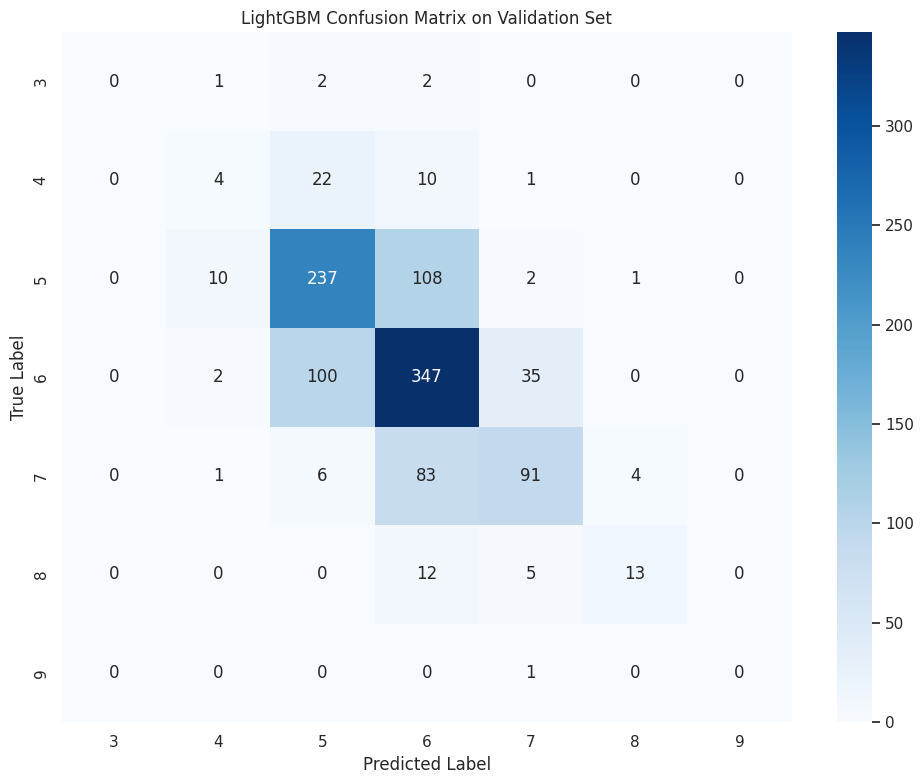

In [115]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. X, y 다시 만들기
X = train.drop(['index', 'quality'], axis=1).copy()
y = train['quality']

# 2. 피처 추가 먼저
X['alcohol_density'] = X['alcohol'] / X['density']

# 3. 그 다음 나누기
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. LightGBM 학습
lgbm_model_for_cm = LGBMClassifier(random_state=42, verbose=-1)
lgbm_model_for_cm.fit(X_train, y_train)

# 5. 예측
y_pred_lgbm_valid = lgbm_model_for_cm.predict(X_valid)

# 6. 혼동행렬
cm_lgbm = confusion_matrix(y_valid, y_pred_lgbm_valid)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lgbm_model_for_cm.classes_,
    yticklabels=lgbm_model_for_cm.classes_
)
plt.title('LightGBM Confusion Matrix on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

 품질 3, 4, 8, 9는 데이터 자체가 적다. 3점짜리는 총 5개밖에 없으니까 모델이 제대로 학습을 이어하지 못하는 것을 알 수 있다

혼동행렬

In [116]:
from sklearn.ensemble import RandomForestClassifier

# 전체 train 데이터로 다시 구성
X_final = train.drop(['index', 'quality'], axis=1).copy()
y_final = train['quality']

# 검증된 feature 추가
X_final['alcohol_density'] = X_final['alcohol'] / X_final['density']

# test도 동일하게 맞춤
test_final = test.drop(['index'], axis=1).copy()
test_final['alcohol_density'] = test_final['alcohol'] / test_final['density']

# 최종 모델 학습
final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_final, y_final)

# 예측
pred_test = final_model.predict(test_final)

In [120]:
print(cm_lgbm)

[[  0   1   2   2   0   0   0]
 [  0   4  22  10   1   0   0]
 [  0  10 237 108   2   1   0]
 [  0   2 100 347  35   0   0]
 [  0   1   6  83  91   4   0]
 [  0   0   0  12   5  13   0]
 [  0   0   0   0   1   0   0]]


당도 / 알코올 비율

In [117]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 기본 데이터
# X = train.drop(['index', 'quality'], axis=1) # X는 이미 정의되었으므로 제거
# y = train['quality'] # y는 이미 정의되었으므로 제거

model = RandomForestClassifier(random_state=42)

# 기본 점수
base_score = cross_val_score(model, X, y, cv=5).mean() # 기존 X, y 사용
print("기본:", base_score)

# 새 feature 추가
X_new = X.copy() # 기존 X를 복사하여 X_new 생성
X_new['sugar_alcohol'] = X_new['residual sugar'] / (X_new['alcohol'] + 1e-6)

# 비교 점수
new_score = cross_val_score(model, X_new, y, cv=5).mean()
print("추가:", new_score)

기본: 0.6732710728761685
추가: 0.6710887583753826


알코올 x 황 조합

In [118]:
X_new = X.copy()
X_new['alcohol_sulfur'] = X_new['alcohol'] * X_new['total sulfur dioxide']

score = cross_val_score(model, X_new, y, cv=5).mean()
print(score)

0.6765466126230458


In [119]:
submission['quality'] = pred_test
submission.to_csv('submission_final_clean.csv', index=False)